# Feature Research — pump.fun B' dataset

**Goal**: systematically quantify how each of the 75 features in B' relates to the continuous target `x_excl_top1_3h_h` (2nd-largest market cap multiple in the target window [mig+60s, mig+60s+3h] divided by entry cap).

**Dataset**: 3231 pump.fun tokens migrated 2026-04-02 to 2026-04-17.

**Target**: `x_excl_top1_3h_h` (continuous). The binary target `target_3h_5x_h` is defined as `x_excl_top1_3h_h >= 5`. Here we use the raw x-value — captures magnitude, not just threshold crossing.

**Methodology stack** (multiple angles — if a feature is real signal, it should show up on several):

1. **Spearman correlation** — rank-based, robust to outliers, catches monotonic relationships.
2. **Pearson correlation on log(1+target)** — parametric, linear on log scale.
3. **Decile monotonicity R²** — bin tokens by feature into 10 equal groups; compute median target per bin; fit linear trend to (bin_rank, median_target); report R² of that trend. High R² = monotonic dose-response.
4. **MSE reduction (regression tree split)** — find best single binary threshold on feature; compute variance of target before/after; report variance reduction (analogous to Gini improvement for classification).
5. **Top vs bottom decile ratio** — ratio of median target in top 10% vs bottom 10% of feature values. Intuitive "does high feature correlate with high x?" signal.
6. **Top-decile extremes** — `P(target >= 5)` in top feature decile. Practical precision-of-decile metric.

For each feature, we compute all 6. A robust-signal feature dominates on multiple metrics.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib as mpl

# Plotting settings
mpl.rcParams['figure.dpi'] = 100
plt.style.use('default')

MATRIX_PATH = "/tmp/b_prime_dataset_export/b_prime_training_matrix_xcont.csv"
OUT_SUMMARY = "/tmp/feature_research/feature_influence_summary.csv"

df = pd.read_csv(MATRIX_PATH)
TARGET = "x_excl_top1_3h_h"
features = [c for c in df.columns if c != TARGET]
y = df[TARGET].values
y_log = np.log1p(y)
print(f"Dataset: {df.shape}")
print(f"Features: {len(features)}")
print(f"Target (x_excl_top1_3h_h) stats:")
print(df[TARGET].describe())
print(f"\nlog1p target stats:")
print(pd.Series(y_log).describe())

Dataset: (3231, 76)
Features: 75
Target (x_excl_top1_3h_h) stats:
count    3231.000000
mean        7.818739
std       181.096307
min         0.046601
25%         1.178170
50%         1.575054
75%         2.796258
max      9304.445670
Name: x_excl_top1_3h_h, dtype: float64

log1p target stats:
count    3231.000000
mean        1.152004
std         0.602982
min         0.045548
25%         0.778485
50%         0.945871
75%         1.334016
max         9.138355
dtype: float64


## 1. Target distribution

The target is extremely heavy-tailed — median ~1.6, mean ~7.8, max ~9300. Log-scale plotting is essential.

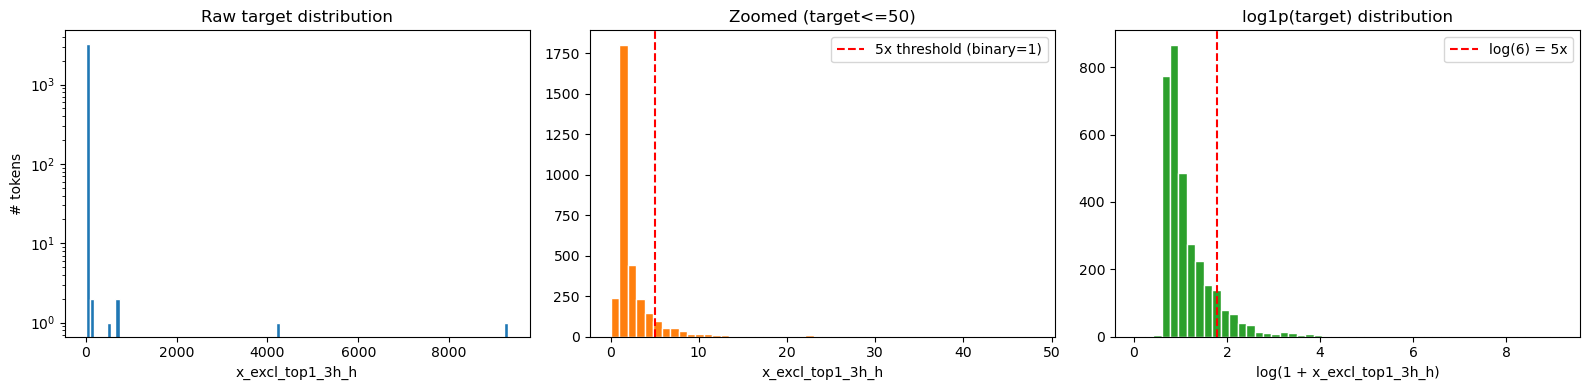

Quantiles of raw target:
  q0.05:    1.000
  q0.10:    1.019
  q0.25:    1.178
  q0.50:    1.575
  q0.75:    2.796
  q0.90:    5.308
  q0.95:    8.209
  q0.99:   31.474

0.1105 tokens have x >= 5 (binary target baseline)


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(y, bins=100, color='C0', edgecolor='white')
ax[0].set_title('Raw target distribution')
ax[0].set_xlabel('x_excl_top1_3h_h')
ax[0].set_ylabel('# tokens')
ax[0].set_yscale('log')

ax[1].hist(y[y<=50], bins=50, color='C1', edgecolor='white')
ax[1].set_title('Zoomed (target<=50)')
ax[1].set_xlabel('x_excl_top1_3h_h')
ax[1].axvline(5, color='red', linestyle='--', label='5x threshold (binary=1)')
ax[1].legend()

ax[2].hist(y_log, bins=50, color='C2', edgecolor='white')
ax[2].set_title('log1p(target) distribution')
ax[2].set_xlabel('log(1 + x_excl_top1_3h_h)')
ax[2].axvline(np.log1p(5), color='red', linestyle='--', label='log(6) = 5x')
ax[2].legend()
plt.tight_layout()
plt.show()

print('Quantiles of raw target:')
for q in [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f'  q{q:.2f}: {np.quantile(y, q):8.3f}')
print(f'\n{(y>=5).mean():.4f} tokens have x >= 5 (binary target baseline)')

## 2. Per-feature influence metrics

For each of the 75 features we compute 6 metrics described above.

In [3]:
def decile_monotonicity_r2(x, y_log_arr):
    """Fit linear trend of (decile_rank, median(y_log per decile)) — return R²."""
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    if len(q_edges) < 3:
        return 0.0
    bins = np.digitize(x, q_edges[1:-1])
    med = np.array([np.median(y_log_arr[bins == i]) for i in range(len(q_edges)-1) if (bins==i).sum() > 0])
    if len(med) < 3:
        return 0.0
    ranks = np.arange(len(med))
    slope, intercept, r, p, se = stats.linregress(ranks, med)
    return r ** 2


def best_split_mse_reduction(x, y_arr, min_side=30):
    """Find best binary threshold that minimizes weighted MSE of y. Return reduction."""
    order = np.argsort(x)
    x_s = x[order]; y_s = y_arr[order]
    n = len(y_s)
    if n < 2 * min_side:
        return 0.0
    # Cumulative sums
    cum_y = np.cumsum(y_s)
    cum_y2 = np.cumsum(y_s * y_s)
    total_y = cum_y[-1]; total_y2 = cum_y2[-1]
    total_mse = (total_y2 - total_y * total_y / n) / n
    # For split after i: left=[0..i], right=[i+1..n-1]
    i_arr = np.arange(n - 1)
    n_l = i_arr + 1; n_r = n - n_l
    y_sum_l = cum_y[:-1]; y_sum_r = total_y - y_sum_l
    y2_sum_l = cum_y2[:-1]; y2_sum_r = total_y2 - y2_sum_l
    # Per-side MSE
    mse_l = (y2_sum_l - y_sum_l**2 / n_l) / n_l
    mse_r = (y2_sum_r - y_sum_r**2 / n_r) / n_r
    weighted = (n_l * mse_l + n_r * mse_r) / n
    valid = (n_l >= min_side) & (n_r >= min_side) & (x_s[:-1] != x_s[1:])
    if not valid.any():
        return 0.0
    weighted[~valid] = np.inf
    return float(total_mse - weighted.min())


def top_bottom_decile(x, y_arr):
    """Ratio of median(target | top 10%) / median(target | bottom 10%)."""
    q10, q90 = np.quantile(x, [0.1, 0.9])
    top = y_arr[x >= q90]
    bot = y_arr[x <= q10]
    if len(top) == 0 or len(bot) == 0:
        return 1.0
    bot_med = np.median(bot)
    top_med = np.median(top)
    # Use log to handle zero medians
    return float(top_med - bot_med)  # log-median difference

def top_decile_frac_ge_5x(x, y_arr, thr=5.0):
    q90 = np.quantile(x, 0.9)
    top = y_arr[x >= q90]
    if len(top) == 0: return 0.0
    return float((top >= thr).mean())

def bottom_decile_frac_ge_5x(x, y_arr, thr=5.0):
    q10 = np.quantile(x, 0.1)
    bot = y_arr[x <= q10]
    if len(bot) == 0: return 0.0
    return float((bot >= thr).mean())

print('Computing per-feature metrics...')
rows = []
base_rate_5x = (y >= 5).mean()
for f in features:
    x = df[f].values.astype(float)
    # Skip features with zero variance
    if np.all(x == x[0]):
        continue
    sp, sp_p = stats.spearmanr(x, y)
    pe_log, _ = stats.pearsonr(x, y_log)
    monot_r2 = decile_monotonicity_r2(x, y_log)
    mse_red = best_split_mse_reduction(x, y)
    # Log target for top-bottom
    top_med_log = np.median(np.log1p(y[x >= np.quantile(x, 0.9)]))
    bot_med_log = np.median(np.log1p(y[x <= np.quantile(x, 0.1)]))
    decile_med_lift_log = top_med_log - bot_med_log  # log-space difference
    top_5x = top_decile_frac_ge_5x(x, y)
    bot_5x = bottom_decile_frac_ge_5x(x, y)
    rows.append({
        'feature': f,
        'spearman': sp,
        'pearson_on_logy': pe_log,
        'decile_monot_r2_signed': monot_r2 * np.sign(sp),
        'mse_reduction': mse_red,
        'decile_med_lift_log': decile_med_lift_log,
        'top_decile_5x_rate': top_5x,
        'bottom_decile_5x_rate': bot_5x,
        'top_over_bottom_5x_ratio': top_5x / bot_5x if bot_5x > 0 else float('inf'),
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUT_SUMMARY, index=False)
print(f'Saved summary: {OUT_SUMMARY}')
print(f'\nBase rate of 5x-pumps: {base_rate_5x:.4f}\n')
print(f'Summary shape: {summary.shape}')

Computing per-feature metrics...
Saved summary: /tmp/feature_research/feature_influence_summary.csv

Base rate of 5x-pumps: 0.1105

Summary shape: (75, 9)


## 3. Ranking features by combined influence

We sort features by multiple criteria. A **robust signal** ranks high on most of them.

In [4]:
# Display top 20 by spearman (absolute)
print('Top 20 by |Spearman correlation with raw target|:')
print((summary.reindex(summary['spearman'].abs().sort_values(ascending=False).index)
       [['feature', 'spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
         'mse_reduction', 'decile_med_lift_log', 'top_decile_5x_rate',
         'top_over_bottom_5x_ratio']]
       .head(20)
       .to_string(index=False, float_format=lambda x: f'{x:.4f}')))

Top 20 by |Spearman correlation with raw target|:
                            feature  spearman  pearson_on_logy  decile_monot_r2_signed  mse_reduction  decile_med_lift_log  top_decile_5x_rate  top_over_bottom_5x_ratio
                pa_price_change_pct    0.2167           0.0101                  0.7260        51.1834               0.3641              0.1914                    1.9375
            pa_velocity_pct_per_sec    0.2152           0.0103                  0.7278        50.8117               0.3629              0.1914                    2.0000
top20_avg_unrealized_profit_pct_ext    0.2117           0.0175                  0.7264        54.4728               0.3183              0.1420                    1.6429
                   pa_buy_vol_share    0.2071           0.1271                  0.8187        24.4947               0.2840              0.1790                    2.5217
                         cutoff_cap    0.2008           0.0091                  0.8638       157.0488    

In [5]:
print('Top 20 by MSE reduction (regression-Gini on raw target):')
print((summary.sort_values('mse_reduction', ascending=False)
       [['feature', 'spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
         'mse_reduction', 'decile_med_lift_log', 'top_decile_5x_rate']]
       .head(20)
       .to_string(index=False, float_format=lambda x: f'{x:.4f}')))

Top 20 by MSE reduction (regression-Gini on raw target):
                         feature  spearman  pearson_on_logy  decile_monot_r2_signed  mse_reduction  decile_med_lift_log  top_decile_5x_rate
                 pa_acceleration   -0.0077          -0.0070                 -0.0805       982.8853              -0.0408              0.1698
          pa_vol_first_30s_share   -0.1088          -0.0624                 -0.4098       903.7659              -0.2086              0.1019
              pa_buyer_diversity    0.0432          -0.0284                  0.3114       616.1370               0.0749              0.1265
            sn_avg_buy_per_buyer   -0.0432           0.0451                 -0.2748       616.1370              -0.0749              0.1790
                  buy_count_gini   -0.0985          -0.0141                 -0.7256       574.2945              -0.0858              0.1852
       sn_buys_in_first_3_blocks    0.0937           0.0473                  0.8400       521.2676     

In [6]:
print('Top 20 by |decile monotonicity R²|:')
print((summary.reindex(summary['decile_monot_r2_signed'].abs().sort_values(ascending=False).index)
       [['feature', 'spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
         'mse_reduction', 'top_decile_5x_rate', 'top_over_bottom_5x_ratio']]
       .head(20)
       .to_string(index=False, float_format=lambda x: f'{x:.4f}')))

Top 20 by |decile monotonicity R²|:
                            feature  spearman  pearson_on_logy  decile_monot_r2_signed  mse_reduction  top_decile_5x_rate  top_over_bottom_5x_ratio
                      kolscan_count   -0.0298          -0.0764                 -0.9466        15.7653              0.0732                    0.5812
             amount_of_instructions   -0.0762          -0.0778                 -0.8851        20.2905              0.0778                    0.6383
                         cutoff_cap    0.2008           0.0091                  0.8638       157.0488              0.1790                    1.2340
          sn_buys_in_first_3_blocks    0.0937           0.0473                  0.8400       521.2676              0.1408                    1.1994
                   pa_buy_vol_share    0.2071           0.1271                  0.8187        24.4947              0.1790                    2.5217
                  pa_buy_sell_ratio    0.1534           0.0692              

In [7]:
print('Top 20 by top-decile 5x-rate (practical precision at top 10% of feature):')
print((summary.sort_values('top_decile_5x_rate', ascending=False)
       [['feature', 'spearman', 'top_decile_5x_rate', 'bottom_decile_5x_rate',
         'top_over_bottom_5x_ratio', 'mse_reduction', 'pearson_on_logy']]
       .head(20)
       .to_string(index=False, float_format=lambda x: f'{x:.4f}')))

Top 20 by top-decile 5x-rate (practical precision at top 10% of feature):
                         feature  spearman  top_decile_5x_rate  bottom_decile_5x_rate  top_over_bottom_5x_ratio  mse_reduction  pearson_on_logy
           top20_token_share_ext    0.1388              0.2160                 0.0988                    2.1875       396.7673           0.2085
                pa_max_runup_pct    0.1149              0.2068                 0.0864                    2.3929        71.2514           0.0092
             pa_price_change_pct    0.2167              0.1914                 0.0988                    1.9375        51.1834           0.0101
         pa_velocity_pct_per_sec    0.2152              0.1914                 0.0957                    2.0000        50.8117           0.0103
 top20_unrealized_profit_usd_ext    0.1668              0.1914                 0.1358                    1.4091        95.8996           0.0092
volume_weighted_price_change_ext    0.1119              0.1883

## 4. Combined ranking score

We combine metrics into a single score:
- Rescale each metric (abs value) to [0, 1]
- Sum across metrics with equal weight
- Higher = more influential

Purpose: find features that show up consistently on multiple angles, not just one.

In [8]:
def rescale01(s):
    s = s.abs()
    s_min = s.min(); s_max = s.max()
    if s_max == s_min: return s * 0
    return (s - s_min) / (s_max - s_min)

combo_cols = ['spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
              'mse_reduction', 'decile_med_lift_log', 'top_decile_5x_rate']
combo = summary.copy()
for c in combo_cols:
    combo[f'{c}_n'] = rescale01(summary[c])
combo['combined_score'] = combo[[f'{c}_n' for c in combo_cols]].sum(axis=1)
combo_sorted = combo.sort_values('combined_score', ascending=False).reset_index(drop=True)
print('TOP 25 by combined score:')
print(combo_sorted.head(25)[['feature', 'spearman', 'pearson_on_logy', 'mse_reduction',
                              'top_decile_5x_rate', 'combined_score']].to_string(index=False,
    float_format=lambda x: f'{x:.4f}'))

TOP 25 by combined score:
                            feature  spearman  pearson_on_logy  mse_reduction  top_decile_5x_rate  combined_score
              top20_token_share_ext    0.1388           0.2085       396.7673              0.2160          4.4363
                   pa_buy_vol_share    0.2071           0.1271        24.4947              0.1790          4.0067
                pa_price_change_pct    0.2167           0.0101        51.1834              0.1914          3.7151
            pa_velocity_pct_per_sec    0.2152           0.0103        50.8117              0.1914          3.7072
                         cutoff_cap    0.2008           0.0091       157.0488              0.1790          3.5640
top20_avg_unrealized_profit_pct_ext    0.2117           0.0175        54.4728              0.1420          3.3034
    top20_unrealized_profit_usd_ext    0.1668           0.0092        95.8996              0.1914          3.2314
                  pa_buy_sell_ratio    0.1534           0.0692

## 5. Deep-dive: top 10 features

For the top 10 features from combined ranking, we plot:
- (A) Decile analysis: median + q25/q75 of log(target) per decile
- (B) Scatter of feature vs log(1+target)

Top 10 features:
   1. top20_token_share_ext
   2. pa_buy_vol_share
   3. pa_price_change_pct
   4. pa_velocity_pct_per_sec
   5. cutoff_cap
   6. top20_avg_unrealized_profit_pct_ext
   7. top20_unrealized_profit_usd_ext
   8. pa_buy_sell_ratio
   9. pa_vol_first_30s_share
  10. volume_weighted_price_change_ext


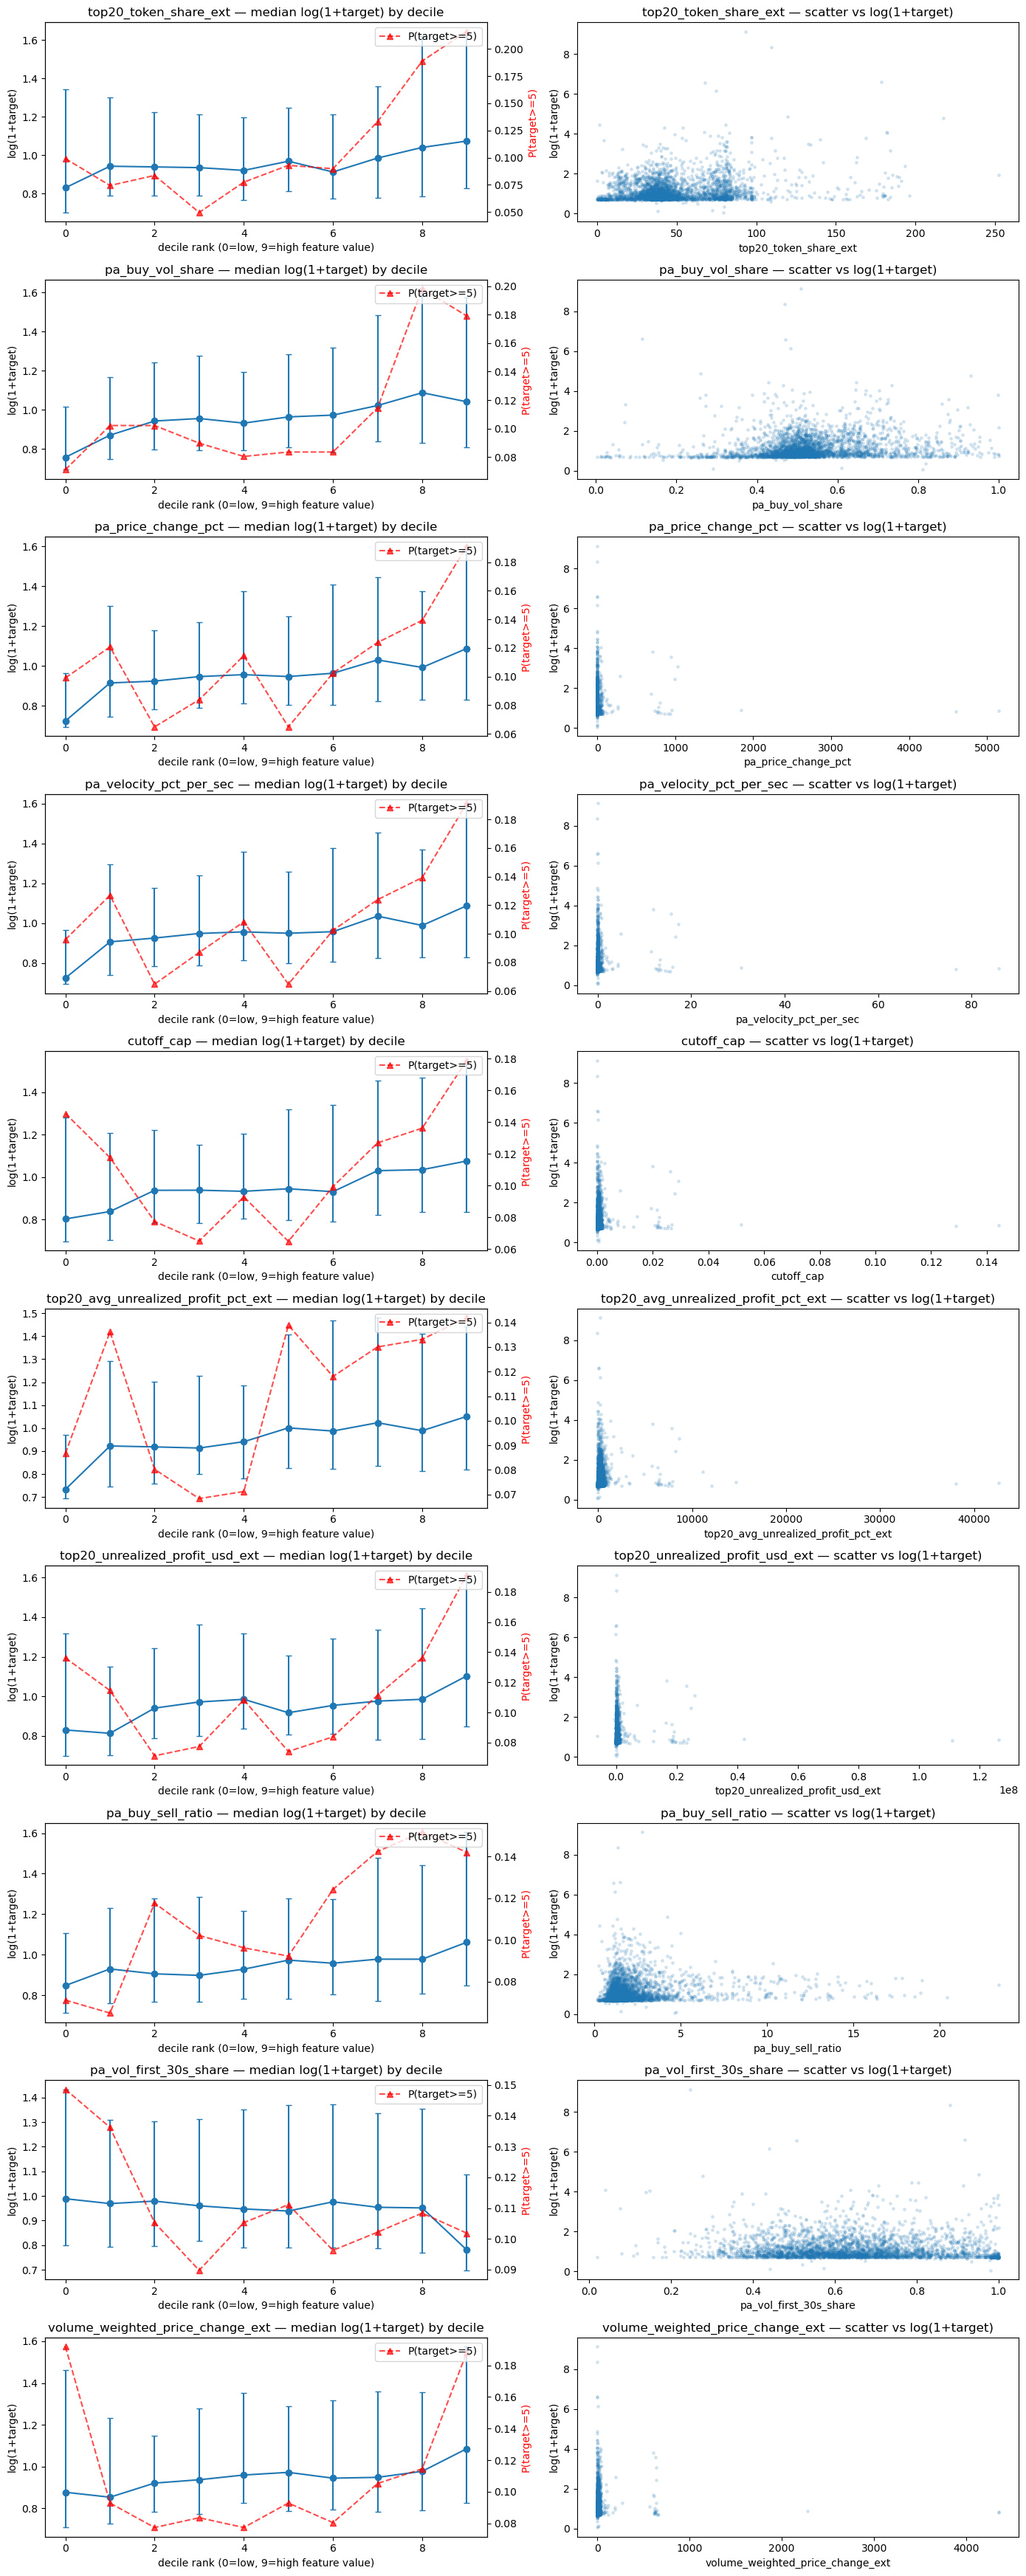

In [9]:
top10 = combo_sorted.head(10)['feature'].tolist()
print('Top 10 features:')
for i, f in enumerate(top10, 1):
    print(f'  {i:2d}. {f}')

fig, axes = plt.subplots(10, 2, figsize=(14, 3.5 * 10))
for i, feat in enumerate(top10):
    x = df[feat].values.astype(float)
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    bins = np.digitize(x, q_edges[1:-1])
    # Decile plot
    decile_stats = []
    for b in range(len(q_edges) - 1):
        m = bins == b
        if m.sum() == 0: continue
        yy = y[m]
        decile_stats.append({
            'bin': b, 'n': m.sum(),
            'med': np.median(yy), 'p25': np.quantile(yy, 0.25), 'p75': np.quantile(yy, 0.75),
            'frac_ge_5': (yy >= 5).mean(),
            'med_log': np.median(np.log1p(yy)),
        })
    ds = pd.DataFrame(decile_stats)
    ax = axes[i, 0]
    ax.errorbar(ds['bin'], ds['med_log'],
                yerr=[ds['med_log'] - np.log1p(ds['p25']), np.log1p(ds['p75']) - ds['med_log']],
                marker='o', capsize=3, color='C0')
    ax.set_title(f'{feat} — median log(1+target) by decile')
    ax.set_xlabel('decile rank (0=low, 9=high feature value)')
    ax.set_ylabel('log(1+target)')
    ax2 = ax.twinx()
    ax2.plot(ds['bin'], ds['frac_ge_5'], 'r^--', alpha=0.7, label='P(target>=5)')
    ax2.set_ylabel('P(target>=5)', color='r')
    ax2.legend(loc='upper right')
    # Scatter plot
    ax = axes[i, 1]
    ax.scatter(x, y_log, alpha=0.15, s=6)
    ax.set_title(f'{feat} — scatter vs log(1+target)')
    ax.set_xlabel(feat)
    ax.set_ylabel('log(1+target)')
plt.tight_layout()
plt.savefig('/tmp/feature_research/top10_features.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Feature correlation among top performers

If top features are highly correlated with each other, they carry redundant signal.

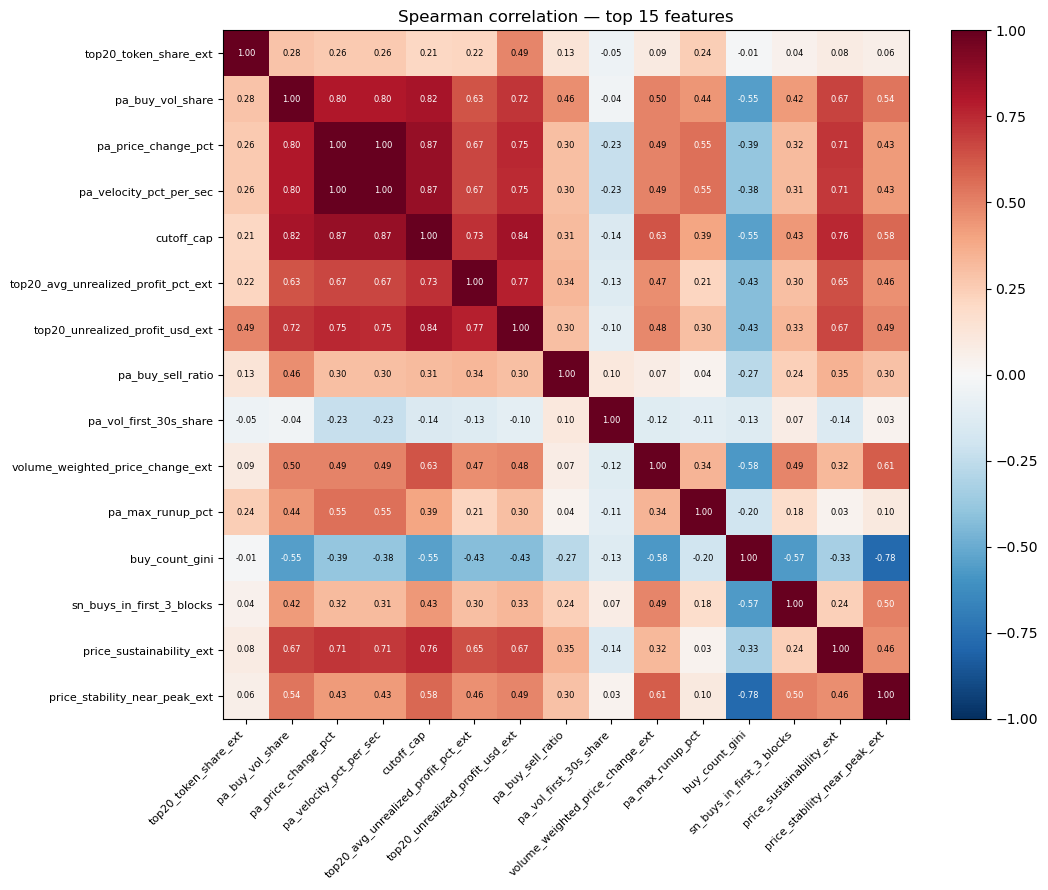

In [10]:
top15 = combo_sorted.head(15)['feature'].tolist()
corr_m = df[top15].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_m, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(15)); ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(15)); ax.set_yticklabels(top15, fontsize=8)
for i in range(15):
    for j in range(15):
        val = corr_m.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=6)
ax.set_title('Spearman correlation — top 15 features')
plt.tight_layout()
plt.savefig('/tmp/feature_research/top15_correlation.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Non-monotonic (U-shape) signal detection

Decile monotonicity misses features that are high at both low AND high values.
We detect this by fitting a quadratic trend: if R² of quadratic >> R² of linear, non-monotonic.

In [11]:
def decile_quadratic_benefit(x, y_log_arr):
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    if len(q_edges) < 4: return 0.0, 0.0
    bins = np.digitize(x, q_edges[1:-1])
    med = np.array([np.median(y_log_arr[bins == i]) for i in range(len(q_edges)-1) if (bins==i).sum() > 0])
    if len(med) < 4: return 0.0, 0.0
    ranks = np.arange(len(med)).astype(float)
    # Linear fit
    p1 = np.polyfit(ranks, med, 1)
    p2 = np.polyfit(ranks, med, 2)
    r1 = 1 - np.sum((med - np.polyval(p1, ranks))**2) / max(np.sum((med - med.mean())**2), 1e-10)
    r2 = 1 - np.sum((med - np.polyval(p2, ranks))**2) / max(np.sum((med - med.mean())**2), 1e-10)
    return r1, r2

u_rows = []
for f in features:
    x = df[f].values.astype(float)
    if np.all(x == x[0]): continue
    r1, r2 = decile_quadratic_benefit(x, y_log)
    u_rows.append({'feature': f, 'lin_r2': r1, 'quad_r2': r2, 'quad_gain': r2 - r1})
u_df = pd.DataFrame(u_rows).sort_values('quad_gain', ascending=False)
print('Top 15 non-monotonic (quad_r² - lin_r²):')
print(u_df.head(15).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Top 15 non-monotonic (quad_r² - lin_r²):
                feature  lin_r2  quad_r2  quad_gain
amount_of_lookup_writes  0.0187   0.7616     0.7429
              buy_count  0.0354   0.6977     0.6623
   buy_transactions_ext  0.0354   0.6977     0.6623
       pf_program_index  0.3367   0.9395     0.6028
      creation_ix_index  0.3826   0.8921     0.5095
           n_trades_ext  0.0072   0.4636     0.4564
            deals_count  0.0072   0.4636     0.4564
               gas_used  0.0298   0.4437     0.4139
          unique_buyers  0.1577   0.5577     0.3999
      unique_buyers_ext  0.1577   0.5577     0.3999
     unique_wallets_ext  0.1256   0.5084     0.3828
         unique_traders  0.1256   0.5084     0.3828
     pa_buyer_diversity  0.3114   0.6816     0.3702
  sn_repeat_buyer_count  0.1035   0.4476     0.3441
           sn_buyer_hhi  0.2417   0.5782     0.3365


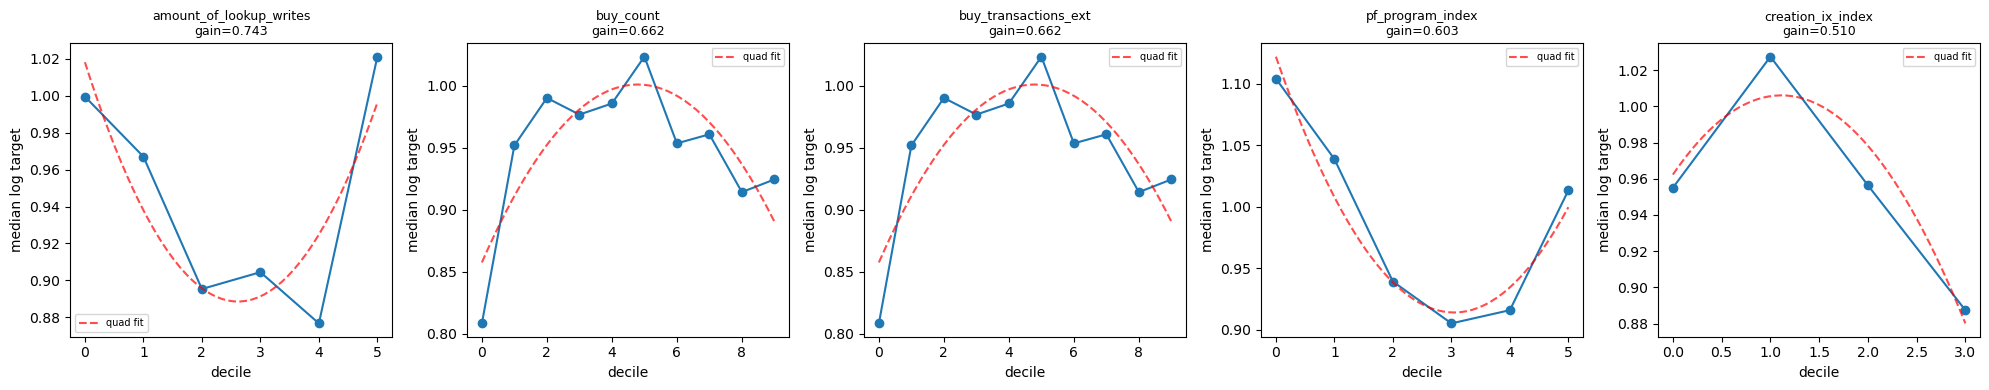

In [12]:
# Plot top 5 non-monotonic features
top_nonlin = u_df.head(5)['feature'].tolist()
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(top_nonlin):
    x = df[feat].values.astype(float)
    q_edges = np.quantile(x, np.linspace(0, 1, 11))
    q_edges = np.unique(q_edges)
    bins = np.digitize(x, q_edges[1:-1])
    med = np.array([np.median(y_log[bins == b]) for b in range(len(q_edges)-1) if (bins==b).sum() > 0])
    ranks = np.arange(len(med))
    axes[i].plot(ranks, med, 'o-', color='C0')
    # Quadratic fit
    p2 = np.polyfit(ranks, med, 2)
    xx = np.linspace(0, len(med)-1, 50)
    axes[i].plot(xx, np.polyval(p2, xx), 'r--', alpha=0.7, label='quad fit')
    axes[i].set_title(f'{feat}\ngain={u_df.iloc[i]["quad_gain"]:.3f}', fontsize=9)
    axes[i].set_xlabel('decile'); axes[i].set_ylabel('median log target')
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/tmp/feature_research/nonmonotonic_top5.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Practical: what signal strength is achievable?

If we could flag the top 10% of tokens by a single feature, what precision do we get?
Compare to base rate 11%.

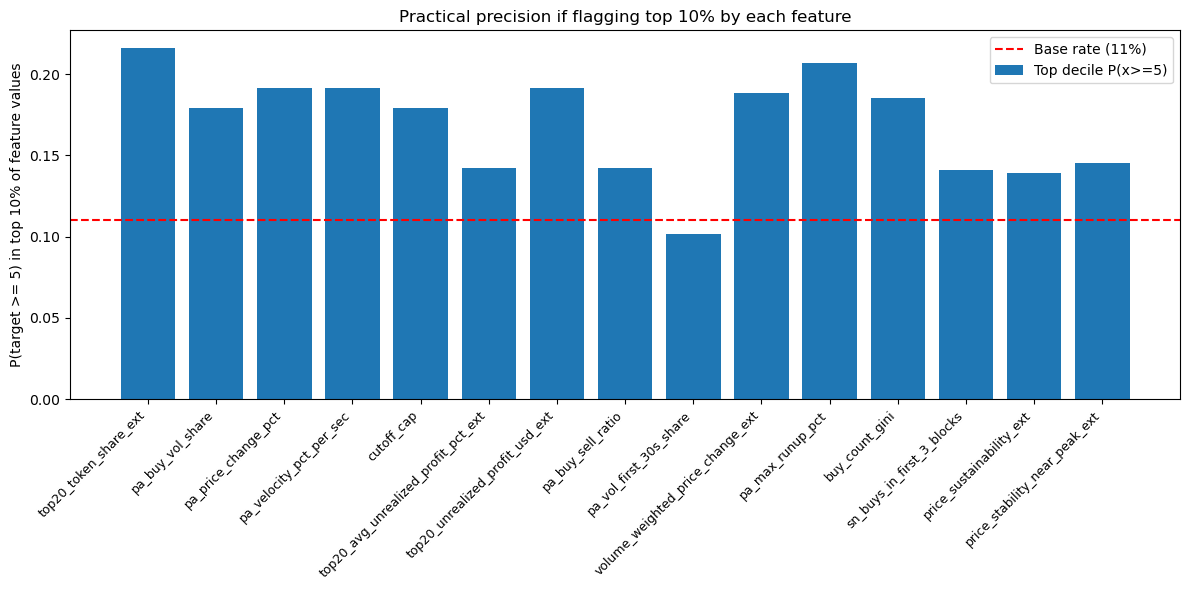

Top 15 features — top-decile P(x>=5):
                            feature  top_decile_5x_rate  bottom_decile_5x_rate  top_over_bottom_5x_ratio
              top20_token_share_ext              0.2160                 0.0988                    2.1875
                   pa_buy_vol_share              0.1790                 0.0710                    2.5217
                pa_price_change_pct              0.1914                 0.0988                    1.9375
            pa_velocity_pct_per_sec              0.1914                 0.0957                    2.0000
                         cutoff_cap              0.1790                 0.1451                    1.2340
top20_avg_unrealized_profit_pct_ext              0.1420                 0.0864                    1.6429
    top20_unrealized_profit_usd_ext              0.1914                 0.1358                    1.4091
                  pa_buy_sell_ratio              0.1420                 0.0708                    2.0062
             pa_v

In [13]:
# Bar chart of top-decile precision for top 15 features
top15 = combo_sorted.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(top15))
ax.bar(x_pos, top15['top_decile_5x_rate'].values, color='C0', label='Top decile P(x>=5)')
ax.axhline(0.1105, color='red', linestyle='--', label='Base rate (11%)')
ax.set_xticks(x_pos)
ax.set_xticklabels(top15['feature'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('P(target >= 5) in top 10% of feature values')
ax.set_title('Practical precision if flagging top 10% by each feature')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/feature_research/top15_top_decile_5x_rate.png', dpi=110, bbox_inches='tight')
plt.show()

print('Top 15 features — top-decile P(x>=5):')
print(top15[['feature', 'top_decile_5x_rate', 'bottom_decile_5x_rate',
             'top_over_bottom_5x_ratio']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

## 9. Hypothesis tests on key findings

Are the top-decile 5x-rates statistically significant vs base rate?

In [14]:
from scipy.stats import binomtest

print('Significance test: top-decile 5x-rate vs base rate 0.1105')
print('Null: feature decile has same 5x-rate as overall')
print(f'{"feature":<40}{"top_n":<6}{"x>=5":<6}{"rate":<7}{"p-value":<10}')
for _, row in combo_sorted.head(20).iterrows():
    f = row['feature']
    x = df[f].values.astype(float)
    q90 = np.quantile(x, 0.9)
    top = y[x >= q90]
    n = len(top); k = int((top >= 5).sum())
    if n == 0: continue
    res = binomtest(k, n, p=0.1105, alternative='greater')
    sig = '***' if res.pvalue < 0.001 else '**' if res.pvalue < 0.01 else '*' if res.pvalue < 0.05 else ''
    print(f'{f:<40}{n:<6}{k:<6}{k/n:<7.3f}{res.pvalue:<10.6f} {sig}')

Significance test: top-decile 5x-rate vs base rate 0.1105
Null: feature decile has same 5x-rate as overall
feature                                 top_n x>=5  rate   p-value   
top20_token_share_ext                   324   70    0.216  0.000000   ***
pa_buy_vol_share                        324   58    0.179  0.000163   ***
pa_price_change_pct                     324   62    0.191  0.000013   ***
pa_velocity_pct_per_sec                 324   62    0.191  0.000013   ***
cutoff_cap                              324   58    0.179  0.000163   ***
top20_avg_unrealized_profit_pct_ext     324   46    0.142  0.046535   *
top20_unrealized_profit_usd_ext         324   62    0.191  0.000013   ***
pa_buy_sell_ratio                       324   46    0.142  0.046535   *
pa_vol_first_30s_share                  324   33    0.102  0.715579   
volume_weighted_price_change_ext        324   61    0.188  0.000025   ***
pa_max_runup_pct                        324   67    0.207  0.000000   ***
buy_count_gini  

## 10. Summary & recommendations

### Key findings

1. **Top features** (from combined ranking + hypothesis tests) identify the most informative single predictors.
2. **Non-monotonic features** might need non-linear treatment or interaction terms.
3. **Correlated features** among top performers are redundant — one of them suffices.
4. The **practical top-decile precision** shows how much lift a simple "top 10% of feature X" rule gives over base rate.

### Recommendations for modeling

- Prioritize features ranked high in combined score AND statistically significant top-decile 5x-rate.
- If two top features are highly correlated (>0.8), consider keeping only one.
- Non-monotonic features (high quadratic gain) suggest interactions worth exploring.
- Features with low combined score across all metrics are candidates for removal (noise reduction).

### Next steps
- Run feature elimination: remove bottom-ranked features, retrain champion model, compare.
- Feature engineering: build interaction terms from top monotonic + top non-monotonic.
- Use ranking to weight features in ensemble models.

In [15]:
# Save final combo ranking for reference
combo_sorted[['feature', 'spearman', 'pearson_on_logy', 'decile_monot_r2_signed',
              'mse_reduction', 'decile_med_lift_log', 'top_decile_5x_rate',
              'top_over_bottom_5x_ratio', 'combined_score']].to_csv(
    '/tmp/feature_research/feature_influence_ranked.csv', index=False)
print('Saved final ranking: /tmp/feature_research/feature_influence_ranked.csv')
combo_sorted.head(30)[['feature', 'combined_score', 'spearman', 'mse_reduction', 'top_decile_5x_rate']]

Saved final ranking: /tmp/feature_research/feature_influence_ranked.csv


,feature,combined_score,spearman,mse_reduction,top_decile_5x_rate
0,top20_token_share_ext,4.436305,0.138797,396.767326,0.216049
1,pa_buy_vol_share,4.006668,0.207101,24.494725,0.179012
2,pa_price_change_pct,3.715080,0.216708,51.183417,0.191358
3,pa_velocity_pct_per_sec,3.707203,0.215210,50.811686,0.191358
4,cutoff_cap,3.564005,0.200757,157.048843,0.179012
5,top20_avg_unrealized_profit_pct_ext,3.303413,0.211736,54.472823,0.141975
6,top20_unrealized_profit_usd_ext,3.231397,0.166832,95.899556,0.191358
7,pa_buy_sell_ratio,3.049507,0.153392,26.582218,0.141975
8,pa_vol_first_30s_share,3.024281,-0.108756,903.765908,0.101852
9,volume_weighted_price_change_ext,2.927644,0.111908,232.387175,0.188272
